# EV Charging Station & Grid Optimization Analysis

**Dataset:** 8,354 EV charging sessions | 27 columns | 20 stations | Jan-Mar 2025
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

## Objective
Clean and explore an EV charging dataset to understand station performance, demand
patterns, cost drivers, and the relationships between charging variables, so that
charging station operators can make better infrastructure and pricing decisions.

## Contents
1. Setup and data loading
2. Data quality checks and cleaning
3. Feature engineering
4. Descriptive statistics and correlation
5. Business questions (Pandas)
6. Statistical analysis (NumPy / SciPy)
7. Visual analysis
8. Findings and limitations

## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [4]:
# Relative path so the notebook runs for anyone who clones the repo.
# Place the CSV inside a /data folder next to this notebook.


df = pd.read_csv(r"C:\Users\user\Downloads\archive (1)\charging_ev_and_grid_optimization_dataset.csv")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()

Rows: 8354 | Columns: 27


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,1/1/2025 0:00,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,48.984550,99.865576,30.528616,7,261.673850,4,15.161672,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,1/1/2025 0:15,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,58.495493,100.000000,41.504507,50,49.916518,3,20.997219,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,1/1/2025 0:30,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,35.711722,95.733464,45.016306,50,54.019568,8,31.606151,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,1/1/2025 0:45,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,29.270825,100.000000,28.291670,11,155.773370,3,21.803050,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,1/1/2025 1:00,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,25.585554,100.000000,55.810835,11,306.369479,5,15.626266,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

## 2. Data quality checks and cleaning

Checks performed: missing values, duplicate rows, and column data types.

In [6]:
# Missing values
missing = df.isnull().sum()
print("Columns with missing values:", (missing > 0).sum())
missing[missing > 0]

Columns with missing values: 0


Series([], dtype: int64)

In [7]:
# Duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)} | Rows remaining: {len(df)}")

Duplicates removed: 0 | Rows remaining: 8354


In [8]:
# Convert time columns from object to datetime so they can be used for
# hour-of-day and time-based grouping.
time_cols = ["timestamp", "arrival_time", "charging_start_time", "charging_end_time"]
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

df[time_cols].dtypes

timestamp              datetime64[ns]
arrival_time           datetime64[ns]
charging_start_time    datetime64[ns]
charging_end_time      datetime64[ns]
dtype: object

In [9]:
# assigned_charger_id is a unique operational identifier with no analytical value
# (one value per session), so it is dropped.
df = df.drop("assigned_charger_id", axis=1)
print("Columns after drop:", df.shape[1])

Columns after drop: 26


## 3. Feature engineering

Four derived columns are created because the raw data does not directly expose
efficiency, revenue, battery outcome, or peak-period behaviour.

| Feature | Formula | Why it matters |
|---|---|---|
| `charging_efficiency` | energy_consumed_kWh / charging_duration | kWh delivered per minute - lets stations be compared on throughput |
| `charging_cost` | energy_consumed_kWh * electricity_price | session revenue - enables revenue analysis by day/station |
| `battery_gain` | final_soc - initial_soc | how much charge the session actually added |
| `peak_hour` | arrival_time hour >= 18 | separates evening peak arrivals from normal hours |

In [10]:
df["charging_efficiency"] = df["energy_consumed_kWh"] / df["charging_duration"]
df["charging_cost"] = df["energy_consumed_kWh"] * df["electricity_price"]
df["battery_gain"] = df["final_soc"] - df["initial_soc"]
df["peak_hour"] = np.where(df["arrival_time"].dt.hour >= 18, "Peak", "Normal")

df[["charging_efficiency", "charging_cost", "battery_gain", "peak_hour"]].head()

,charging_efficiency,charging_cost,battery_gain,peak_hour
0,0.116667,417.020892,50.881026,Normal
1,0.831478,227.029655,41.504507,Normal
2,0.833333,427.654911,60.021742,Normal
3,0.181621,175.974187,70.729175,Normal
4,0.182168,748.981401,74.414446,Normal


## 4. Descriptive statistics and correlation

In [11]:
df.describe().round(2)

,timestamp,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward,charging_efficiency,charging_cost,battery_gain
count,8354,8354,8354,8354,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00,8354.00
mean,2025-02-13 12:07:30,2025-02-13 12:07:30,2025-02-13 12:17:01.580081408,2025-02-13 15:15:13.567153664,9.53,61.08,34.81,98.50,39.08,22.45,178.70,4.59,53.18,9.96,0.35,53.16,-11.83,0.36,389.59,63.69
min,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 01:12:00,0.00,30.00,10.00,65.08,7.50,7.00,10.00,0.00,10.05,5.00,0.10,5.51,-43.29,0.11,41.90,20.83
25%,2025-01-22 18:03:45,2025-01-22 18:03:45,2025-01-22 18:16:45,2025-01-22 22:15:15,6.00,40.00,22.37,98.46,23.68,11.00,64.12,3.00,28.03,7.51,0.21,27.91,-18.35,0.16,217.73,51.13
50%,2025-02-13 12:07:30,2025-02-13 12:07:30,2025-02-13 12:17:00,2025-02-13 14:46:30,9.00,60.00,34.64,100.00,35.15,11.00,133.70,5.00,49.42,9.96,0.31,49.51,-11.27,0.18,336.59,63.81
75%,2025-03-07 06:11:15,2025-03-07 06:11:15,2025-03-07 06:16:30,2025-03-07 09:33:15,13.00,75.00,47.31,100.00,51.36,22.00,247.95,7.00,77.60,12.40,0.46,77.85,-5.11,0.37,511.46,76.22
max,2025-03-29 00:15:00,2025-03-29 00:15:00,2025-03-29 00:34:00,2025-03-29 07:00:00,28.00,100.00,59.99,100.00,89.93,50.00,776.55,15.00,100.00,15.00,0.80,104.99,14.18,0.83,1308.16,90.00
std,NaN,NaN,NaN,NaN,4.89,25.00,14.48,3.26,18.97,16.81,149.12,2.83,27.38,2.88,0.19,27.56,9.27,0.27,226.93,14.84


In [12]:
corr = df.corr(numeric_only=True)
corr.round(2)

,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward,charging_efficiency,charging_cost,battery_gain
waiting_time,1.00,0.00,0.01,-0.02,-0.01,0.01,-0.01,-0.00,-0.02,-0.00,0.00,-0.02,-0.52,0.01,-0.00,-0.01
battery_capacity_kWh,0.00,1.00,-0.01,0.19,0.86,0.00,0.49,0.01,0.00,0.00,-0.02,-0.00,-0.01,0.02,0.72,0.05
initial_soc,0.01,-0.01,1.00,-0.00,-0.47,-0.02,-0.26,0.00,-0.00,-0.01,-0.02,-0.00,-0.01,-0.03,-0.39,-0.98
final_soc,-0.02,0.19,-0.00,1.00,0.23,-0.35,0.30,0.00,0.01,-0.01,-0.00,0.01,0.00,-0.39,0.19,0.22
energy_consumed_kWh,-0.01,0.86,-0.47,0.23,1.00,-0.02,0.58,0.00,0.00,0.01,-0.01,-0.00,-0.00,-0.01,0.83,0.51
charging_power_kW,0.01,0.00,-0.02,-0.35,-0.02,1.00,-0.65,0.01,-0.02,-0.00,0.01,-0.02,0.01,0.99,-0.02,-0.06
charging_duration,-0.01,0.49,-0.26,0.30,0.58,-0.65,1.00,-0.01,0.02,0.01,-0.01,0.02,-0.01,-0.64,0.48,0.32
queue_length,-0.00,0.01,0.00,0.00,0.00,0.01,-0.01,1.00,0.07,-0.01,-0.00,0.07,-0.19,0.01,-0.01,-0.00
station_load,-0.02,0.00,-0.00,0.01,0.00,-0.02,0.02,0.07,1.00,-0.01,0.02,0.99,-0.58,-0.02,-0.01,0.00
electricity_price,-0.00,0.00,-0.01,-0.01,0.01,-0.00,0.01,-0.01,-0.01,1.00,-0.01,-0.01,0.00,0.00,0.50,0.01


## 5. Business questions (Pandas)

### Q1. Which charging stations have the highest average charging efficiency?

In [13]:
station_efficiency = (
    df.groupby("station_id")["charging_efficiency"]
      .mean()
      .sort_values(ascending=False)
      .round(4)
)
station_efficiency.head(5)

station_id
ST009    0.3941
ST015    0.3826
ST010    0.3784
ST011    0.3753
ST001    0.3750
Name: charging_efficiency, dtype: float64

### Q2. Which stations perform best on optimization reward?

In [14]:
station_reward = (
    df.groupby("station_id")["optimization_reward"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
      .round(2)
)
station_reward.head(5)

,sum,mean,count
station_id,,,
ST016,-4480.77,-11.58,387
ST020,-4516.55,-10.96,412
ST007,-4671.01,-11.95,391
ST002,-4767.50,-11.98,398
ST015,-4782.34,-11.50,416


### Q3. Does weather condition affect charging demand?

In [15]:
weather_demand = (
    df.groupby("weather_condition")["charging_demand"]
      .agg(["mean", "std", "count"])
      .sort_values("mean", ascending=False)
      .round(2)
)
weather_demand

,mean,std,count
weather_condition,,,
Clear,53.46,27.66,2740
Rainy,53.20,27.49,2854
Cloudy,52.81,27.55,2760


### Q4. Which day of the week generates the highest charging revenue?

In [16]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

day_revenue = (
    df.groupby("day_of_week")["charging_cost"]
      .sum()
      .reindex(day_order)
      .round(2)
)
day_revenue

day_of_week
Monday       439924.21
Tuesday      450027.65
Wednesday    495634.19
Thursday     483257.72
Friday       489045.89
Saturday     459226.80
Sunday       437508.44
Name: charging_cost, dtype: float64

### Q5. Which vehicle type charges for the longest, and does it differ?

In [17]:
vehicle_duration = (
    df.groupby("vehicle_type")["charging_duration"]
      .agg(["mean", "std", "count"])
      .sort_values("mean", ascending=False)
      .round(2)
)
vehicle_duration

,mean,std,count
vehicle_type,,,
Car,179.65,150.81,2833
Bus,179.01,151.10,2760
Two-Wheeler,177.42,145.38,2761


## 6. Statistical analysis (NumPy / SciPy)

### Q6. Normalise energy consumed to a 0-1 scale

In [18]:
energy = df["energy_consumed_kWh"].values
energy_normalised = (energy - energy.min()) / (energy.max() - energy.min())

print("Min:", energy_normalised.min(), "| Max:", energy_normalised.max())
energy_normalised[:10].round(4)

Min: 0.0 | Max: 1.0


array([0.2794, 0.4125, 0.4551, 0.2522, 0.5861, 0.4559, 0.1854, 0.4917,
       0.5583, 0.3705])

### Q7. Covariance between charging power and optimization reward

In [19]:
cov_matrix = np.cov(df["charging_power_kW"], df["optimization_reward"])
corr_value = df["charging_power_kW"].corr(df["optimization_reward"])

print("Covariance matrix:\n", cov_matrix.round(2))
print("\nPearson correlation:", round(corr_value, 4))

Covariance matrix:
 [[282.69   1.32]
 [  1.32  85.97]]

Pearson correlation: 0.0085


### Q8. Detect outliers in charging duration using Z-score

In [20]:
z_scores = np.abs(zscore(df["charging_duration"]))
outliers = df[z_scores > 3]

print(f"Outlier sessions (|z| > 3): {len(outliers)} "
      f"({len(outliers) / len(df) * 100:.2f}% of all sessions)")

outliers[["station_id", "vehicle_type", "charging_duration",
          "energy_consumed_kWh", "charging_cost"]].head()

Outlier sessions (|z| > 3): 139 (1.66% of all sessions)


,station_id,vehicle_type,charging_duration,energy_consumed_kWh,charging_cost
25,ST006,Two-Wheeler,684.979325,79.914255,1147.568696
43,ST002,Car,678.834224,78.871179,461.396398
92,ST017,Car,766.611830,89.438047,671.679731
104,ST018,Bus,757.108824,87.895341,1279.756158
122,ST009,Bus,712.301343,82.520968,907.730647


## 7. Visual analysis

### Top 10 stations by total charging demand

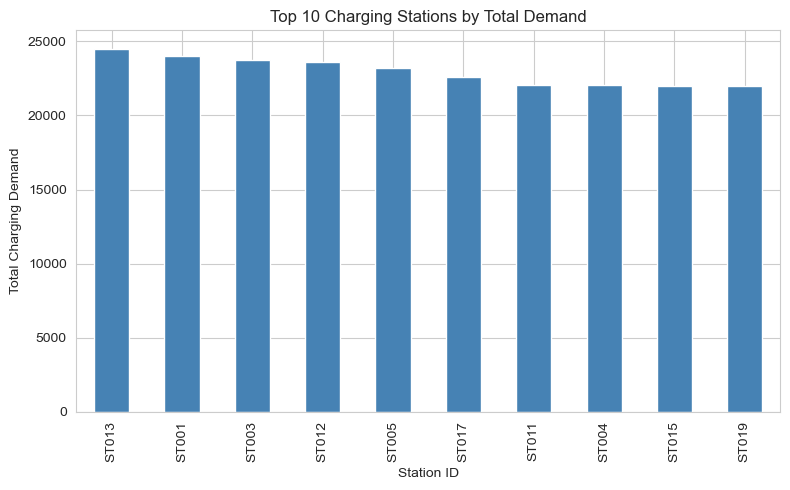

In [21]:
top_stations = df.groupby("station_id")["charging_demand"].sum().nlargest(10)

top_stations.plot(kind="bar", figsize=(8, 5), color="steelblue")
plt.title("Top 10 Charging Stations by Total Demand")
plt.xlabel("Station ID")
plt.ylabel("Total Charging Demand")
plt.tight_layout()
plt.show()

### Vehicle type distribution

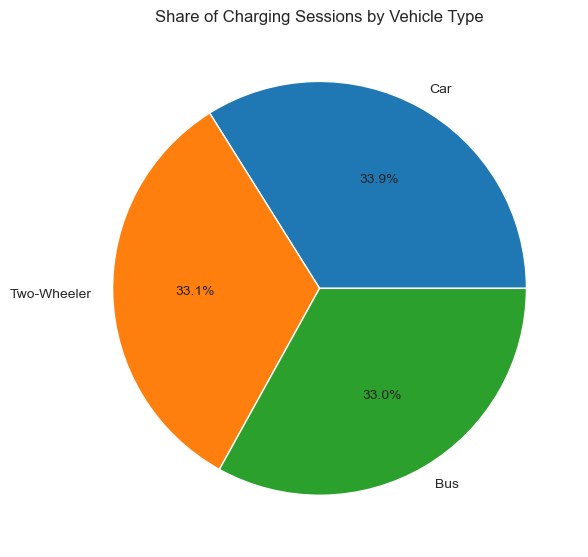

In [22]:
df["vehicle_type"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", figsize=(6, 6), ylabel=""
)
plt.title("Share of Charging Sessions by Vehicle Type")
plt.tight_layout()
plt.show()

### Charging duration distribution

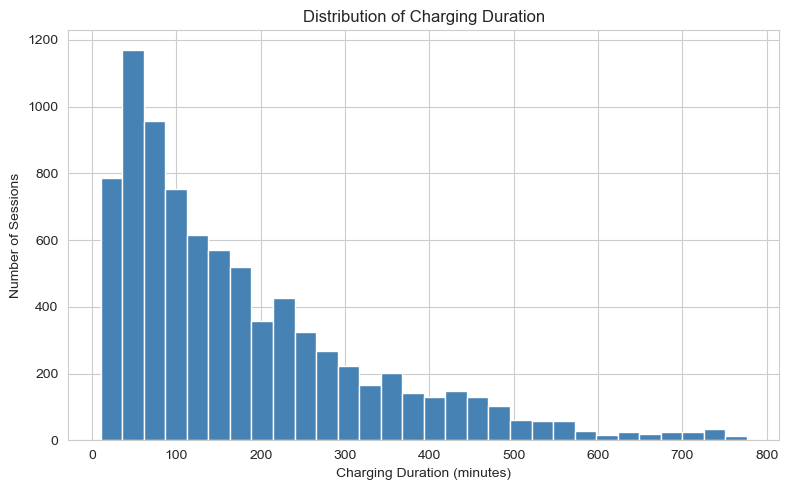

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df["charging_duration"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of Charging Duration")
plt.xlabel("Charging Duration (minutes)")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

### Energy consumed vs charging cost

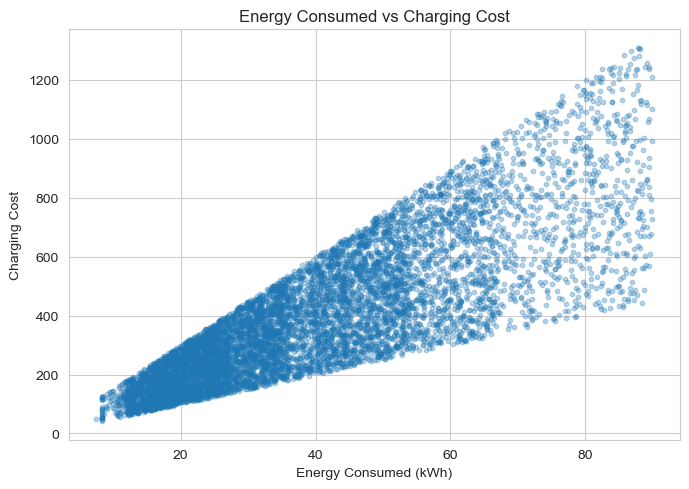

In [24]:
plt.figure(figsize=(7, 5))
plt.scatter(df["energy_consumed_kWh"], df["charging_cost"], alpha=0.3, s=10)
plt.title("Energy Consumed vs Charging Cost")
plt.xlabel("Energy Consumed (kWh)")
plt.ylabel("Charging Cost")
plt.tight_layout()
plt.show()

### Correlation heatmap

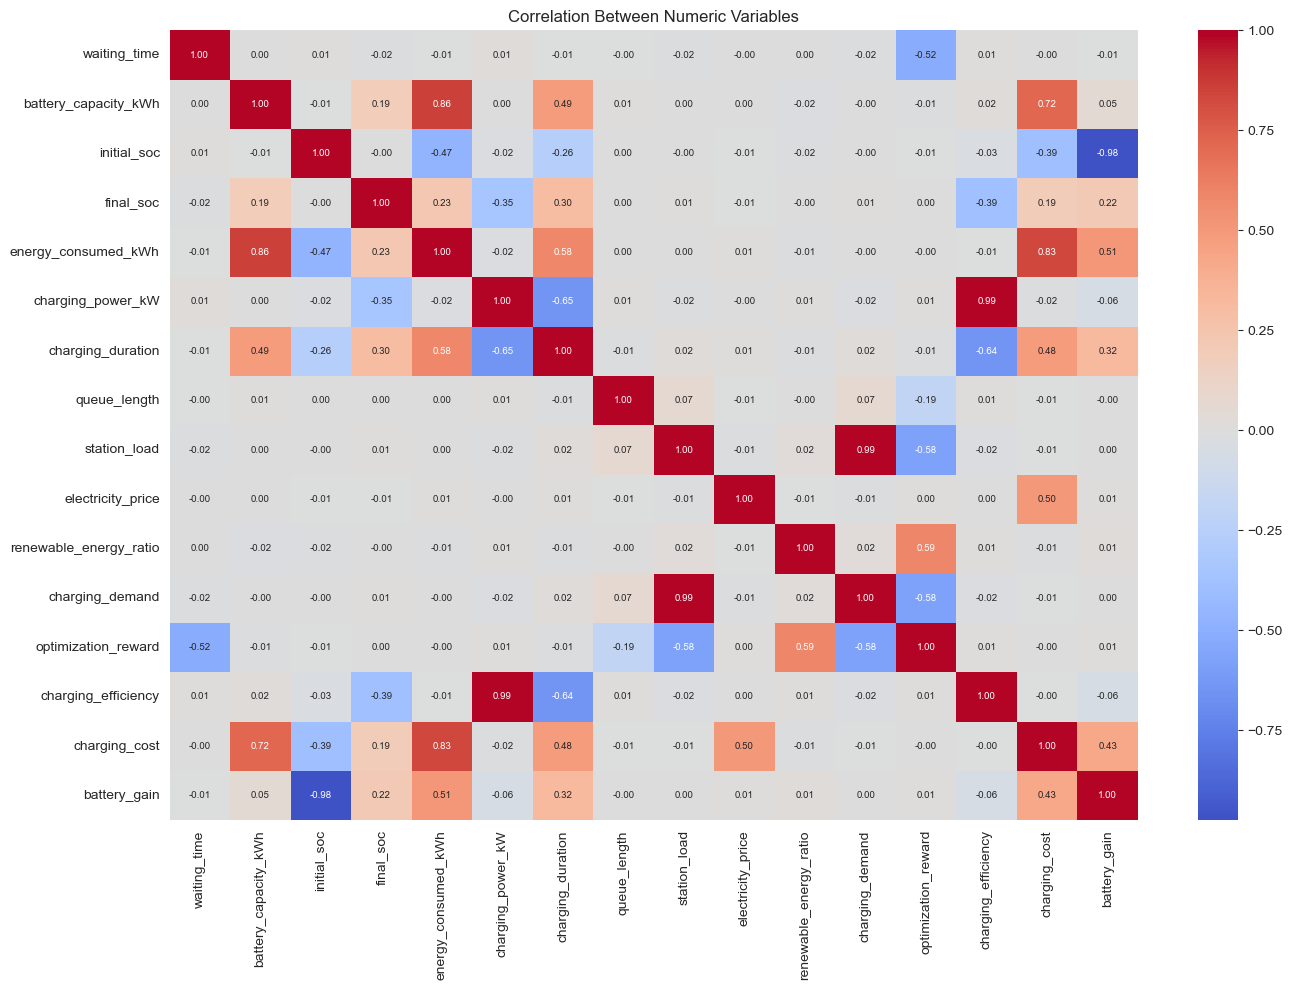

In [25]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.show()

### Charging demand by time slot

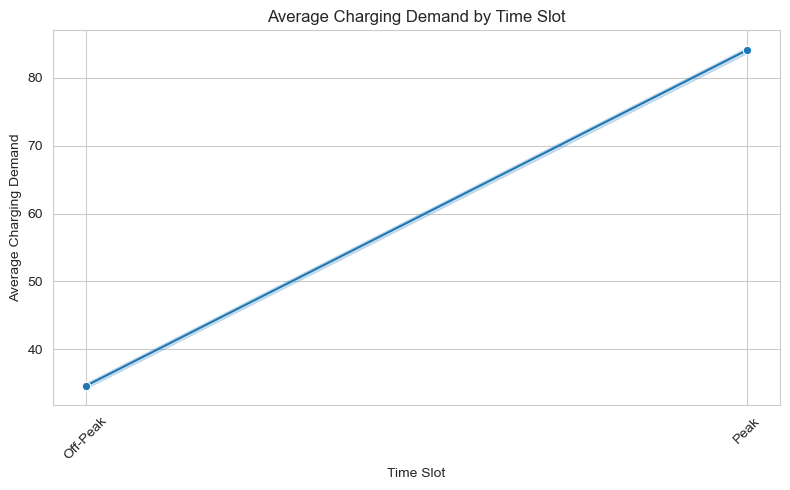

In [26]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="time_slot", y="charging_demand", marker="o")
plt.title("Average Charging Demand by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Average Charging Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Charging duration by weather condition

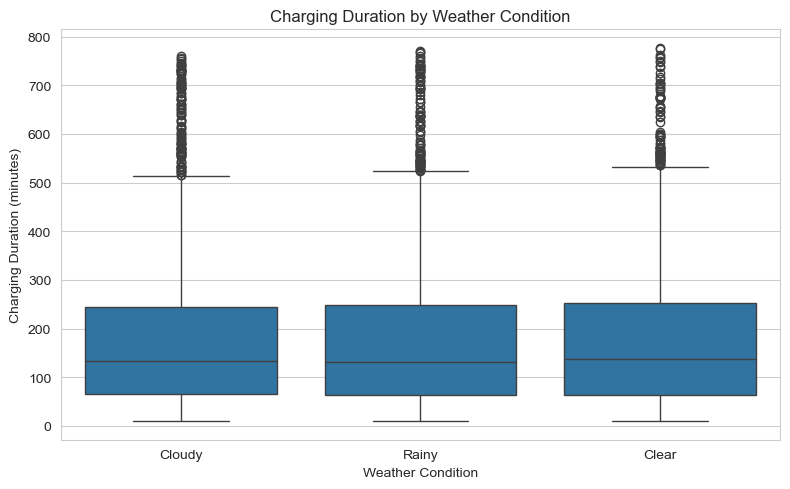

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="weather_condition", y="charging_duration", data=df)
plt.title("Charging Duration by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Charging Duration (minutes)")
plt.tight_layout()
plt.show()

## 8. Findings and limitations

### What the analysis did
- Cleaned and validated 8,354 charging sessions across 27 columns and 20 stations.
- Converted four time columns to datetime and removed a non-analytical identifier column.
- Engineered four features (charging efficiency, charging cost, battery gain, peak-hour flag)
  that are not present in the raw data.
- Ranked stations by efficiency and optimization reward, compared revenue across days of
  the week, and tested whether weather and vehicle type change charging behaviour.
- Applied min-max normalisation, covariance analysis, and Z-score outlier detection.
- Produced seven visualisations covering demand, distribution, cost, and correlation.

### What the data actually shows
- **Differences between groups are very small.** Average charging demand varies by roughly
  1% across weather conditions, and average charging duration varies by about 1% across
  vehicle types. These gaps are well inside normal variation and should not be treated as
  real effects.
- **Most numeric variables are weakly correlated.** The clearest relationship is the
  mechanical one between energy consumed and charging cost, which exists by construction
  since cost is derived from energy.
- **Optimization reward is negative for every station**, with a narrow spread, so station
  rankings on this metric are not meaningful.

### Limitations
- The dataset appears to be synthetic or randomly generated. Variables that would be
  strongly linked in real operations (vehicle type and charging duration, weather and
  demand) show almost no relationship.
- Because of this, the analysis is best read as a demonstration of EDA method rather than
  as a source of operational conclusions.
- A real version of this analysis would need observed station data, and the group
  differences would need significance testing before being acted on.